# Phase 2 v3: Feature Engineering (Fixed)

### What changed from v1

**v1 had three critical problems:**
1. Normal class was 90.7% of data (21,840 vs ~300 per suspicious class) - model never predicted normal
2. All 7 classes trained together - too many similar classes, confusing a small model
3. Features computed in crop-normalised coordinates - absorbed the very movements we need to detect

**v3 fixes:**

| Fix | Problem | Solution |
|-----|---------|----------|
| **Fix 1** | 45:1 normal-to-suspicious ratio | Only 1 random non-target person per clip (not all 7) |
| **Fix 2** | 7-class problem too hard | Two-stage: binary (normal/suspicious) then 6-class subtype |
| **Fix 3** | Features in crop coords not discriminative | Features in frame coords + relative-to-rest-position baseline |


---
## 1. Setup

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
    'numpy', 'pandas', 'matplotlib', 'seaborn', 'scikit-learn'])
print('Dependencies ready.')

Dependencies ready.


In [2]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print('Imports done.')

Imports done.


In [3]:
#  UPDATE THIS PATH                                          

DATA_DIR = '/home/sagemaker-user/exam_proctoring_dataset'

POSES_DIR  = os.path.join(DATA_DIR, 'poses')
LABELS_CSV = os.path.join(DATA_DIR, 'clip_labels_master.csv')
SUMMARY_CSV= os.path.join(DATA_DIR, 'poses', 'extraction_summary.csv')
QUALITY_CSV= os.path.join(DATA_DIR, 'poses', 'pose_quality_report.csv')
OUTPUT_DIR = os.path.join(DATA_DIR, 'training_outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

FEATURES_CHECKPOINT = os.path.join(OUTPUT_DIR, 'features_v2_checkpoint.pkl')

# Config
WINDOW_SIZE_SEC   = 3.0
WINDOW_STRIDE_SEC = 1.0
MIN_VISIBILITY    = 0.5
ACTIVE_THRESHOLD  = 0.6
MAX_NORMAL_PER_CLIP = 1   # FIX 1: only 1 non-target person per clip

CLASS_NAMES = ['normal','looking_sideways','leaning_to_neighbor',
               'using_phone','talking_to_neighbor','looking_down','passing_note']
SEED = 42
np.random.seed(SEED)

def save_checkpoint(data, path):
    with open(path, 'wb') as f: pickle.dump(data, f)
    print(f'Saved: {path} ({os.path.getsize(path)/1024/1024:.1f} MB)')

def load_checkpoint(path):
    if os.path.exists(path):
        with open(path, 'rb') as f: data = pickle.load(f)
        print(f'CHECKPOINT FOUND: {path}')
        return data
    return None

for p, n in [(POSES_DIR,'Poses'),(LABELS_CSV,'Labels')]:
    print(f'  {n}: {"FOUND" if os.path.exists(p) else "MISSING"}')

  Poses: FOUND
  Labels: FOUND


---
## 2. Load Data

In [4]:
df_labels = pd.read_csv(LABELS_CSV, encoding='utf-8-sig')
df_labels = df_labels[df_labels['review_status'].str.strip() == 'complete'].copy()
df_labels['clip_stem'] = df_labels['clip_name'].str.replace('.mp4', '', regex=False)

df_summary = pd.read_csv(SUMMARY_CSV, encoding='utf-8-sig')
df_summary['clip_stem'] = df_summary['clip_name'].str.replace('.mp4', '', regex=False)

df = df_labels.merge(
    df_summary[['clip_stem','total_frames','sampled_frames','fps','avg_people_detected']],
    on='clip_stem', how='inner'
)

print(f'Clips: {len(df)}')
print(f'\nClass distribution:')
print(df['behavior_class'].value_counts().to_string())

Clips: 393

Class distribution:
behavior_class
normal                 104
leaning_to_neighbor     63
looking_sideways        55
using_phone             54
talking_to_neighbor     46
looking_down            42
passing_note            29


---
## 3. Improved Feature Functions

**New features added:**
- `head_turn_velocity` - rate of change (catches rapid back-and-forth)
- `ear_asymmetry` - difference (not ratio) between ear visibilities
- `nose_shoulder_dist` - vertical distance nose-to-shoulder midpoint (more direct than head_pitch)
- `wrist_below_desk` - binary-ish: how far wrist is below the desk plane (hip level)

In [5]:
def kp_to_frame_coords(kp, bbox):
    """
    Convert crop-normalised keypoints back to frame pixel coordinates.
    
    Args:
        kp:   (33, 4) — x, y, z, visibility (x,y normalised to crop 0-1)
        bbox: (4,) — x1, y1, x2, y2 in frame pixels
    
    Returns:
        (33, 4) — x, y now in frame pixels; z and visibility unchanged
    """
    result = kp.copy()
    x1, y1, x2, y2 = bbox
    w = x2 - x1
    h = y2 - y1
    if w > 0 and h > 0:
        result[:, 0] = x1 + kp[:, 0] * w  # x in frame pixels
        result[:, 1] = y1 + kp[:, 1] * h  # y in frame pixels
    return result

print('Frame coordinate converter ready.')

Frame coordinate converter ready.


In [6]:
def safe_angle(v1, v2):
    n1, n2 = np.linalg.norm(v1), np.linalg.norm(v2)
    if n1 < 1e-6 or n2 < 1e-6: return 0.0
    cos = np.clip(np.dot(v1, v2) / (n1*n2), -1.0, 1.0)
    return np.degrees(np.arccos(cos))


def compute_frame_features_v2(kp_frame, prev_kp_frame, ref_shoulder_w):
    """
    Compute features from keypoints in FRAME coordinates.
    
    Args:
        kp_frame:       (33, 4) — keypoints in frame pixel coords
        prev_kp_frame:  (33, 4) or None — previous frame
        ref_shoulder_w: float — median shoulder width for this person (pixels)
    
    Returns: dict of feature_name -> float
    """
    feat = {}
    vis = kp_frame[:, 3]
    sw = max(ref_shoulder_w, 1.0)  # prevent division by zero
    
    def pt(idx):
        return kp_frame[idx, :2] if vis[idx] >= MIN_VISIBILITY else None
    
    nose=pt(0); l_ear=pt(7); r_ear=pt(8); mouth_l=pt(9); mouth_r=pt(10)
    l_sh=pt(11); r_sh=pt(12); l_el=pt(13); r_el=pt(14)
    l_wr=pt(15); r_wr=pt(16); l_hip=pt(23); r_hip=pt(24)
    
    mid_sh = (l_sh + r_sh) / 2 if (l_sh is not None and r_sh is not None) else None
    mid_hip = (l_hip + r_hip) / 2 if (l_hip is not None and r_hip is not None) else None
    
    # ── F1: Head turn (pixels / shoulder_width) ──
    # Positive = nose right of shoulder midpoint
    if nose is not None and mid_sh is not None:
        feat['head_turn'] = (nose[0] - mid_sh[0]) / sw
    else:
        feat['head_turn'] = 0.0
    
    # ── F2: Head turn velocity (change from prev frame) ──
    # High values = rapid head movement
    feat['head_turn_vel'] = 0.0
    if prev_kp_frame is not None and nose is not None and mid_sh is not None:
        pv = prev_kp_frame[:, 3]
        if pv[0] >= MIN_VISIBILITY and pv[11] >= MIN_VISIBILITY and pv[12] >= MIN_VISIBILITY:
            prev_nose = prev_kp_frame[0, :2]
            prev_mid = (prev_kp_frame[11, :2] + prev_kp_frame[12, :2]) / 2
            prev_ht = (prev_nose[0] - prev_mid[0]) / sw
            feat['head_turn_vel'] = abs(feat['head_turn'] - prev_ht)
    
    # ── F3: Nose-shoulder vertical distance (pixels / shoulder_width) ──
    # Larger = head more dropped (looking_down)
    if nose is not None and mid_sh is not None:
        feat['nose_shoulder_dist'] = (nose[1] - mid_sh[1]) / sw
    else:
        feat['nose_shoulder_dist'] = 0.0
    
    # ── F4: Torso lean angle (degrees) ──
    if mid_sh is not None and mid_hip is not None:
        torso = mid_hip - mid_sh
        angle = safe_angle(torso, np.array([0, 1]))
        feat['torso_lean'] = (1.0 if torso[0] > 0 else -1.0) * angle
    else:
        feat['torso_lean'] = 0.0
    
    # ── F5: Shoulder tilt (degrees from horizontal) ──
    if l_sh is not None and r_sh is not None:
        feat['shoulder_tilt'] = safe_angle(r_sh - l_sh, np.array([1, 0]))
    else:
        feat['shoulder_tilt'] = 0.0
    
    # ── F6-F7: Wrist drop (pixels below shoulder / sw) ──
    feat['l_wrist_drop'] = ((l_wr[1] - mid_sh[1]) / sw) if (l_wr is not None and mid_sh is not None) else 0.0
    feat['r_wrist_drop'] = ((r_wr[1] - mid_sh[1]) / sw) if (r_wr is not None and mid_sh is not None) else 0.0
    
    # ── F8-F9: Wrist lateral extent (pixels beyond shoulder / sw) ──
    feat['l_wrist_extent'] = ((l_sh[0] - l_wr[0]) / sw) if (l_wr is not None and l_sh is not None) else 0.0
    feat['r_wrist_extent'] = ((r_wr[0] - r_sh[0]) / sw) if (r_wr is not None and r_sh is not None) else 0.0
    
    # ── F10: Wrist below desk plane (how far below hip level / sw) ──
    # Positive = wrist below hip (reaching under desk for phone)
    feat['wrist_below_desk'] = 0.0
    if mid_hip is not None:
        drops = []
        if l_wr is not None: drops.append((l_wr[1] - mid_hip[1]) / sw)
        if r_wr is not None: drops.append((r_wr[1] - mid_hip[1]) / sw)
        if drops: feat['wrist_below_desk'] = max(drops)
    
    # ── F11: Ear asymmetry (difference, not ratio) ──
    # High absolute value = head turned (one ear hidden)
    l_ev = vis[7] if vis[7] >= 0.1 else 0.0
    r_ev = vis[8] if vis[8] >= 0.1 else 0.0
    feat['ear_asymmetry'] = abs(l_ev - r_ev)
    
    # ── F12: Mouth movement (frame-to-frame) ──
    feat['mouth_movement'] = 0.0
    if prev_kp_frame is not None and mouth_l is not None and mouth_r is not None:
        pv = prev_kp_frame[:, 3]
        if pv[9] >= MIN_VISIBILITY and pv[10] >= MIN_VISIBILITY:
            dl = np.linalg.norm(mouth_l - prev_kp_frame[9, :2])
            dr = np.linalg.norm(mouth_r - prev_kp_frame[10, :2])
            feat['mouth_movement'] = (dl + dr) / (2 * sw)
    
    # ── F13: Body movement (frame-to-frame, normalised) ──
    feat['body_movement'] = 0.0
    if prev_kp_frame is not None:
        mv = 0.0; cnt = 0
        for idx in [0, 11, 12, 15, 16]:
            if vis[idx] >= MIN_VISIBILITY and prev_kp_frame[idx, 3] >= MIN_VISIBILITY:
                mv += np.linalg.norm(kp_frame[idx, :2] - prev_kp_frame[idx, :2])
                cnt += 1
        if cnt > 0: feat['body_movement'] = mv / (cnt * sw)
    
    return feat


FEATURE_NAMES_V2 = [
    'head_turn', 'head_turn_vel', 'nose_shoulder_dist',
    'torso_lean', 'shoulder_tilt',
    'l_wrist_drop', 'r_wrist_drop', 'l_wrist_extent', 'r_wrist_extent',
    'wrist_below_desk', 'ear_asymmetry', 'mouth_movement', 'body_movement',
]
NUM_BASE = len(FEATURE_NAMES_V2)
print(f'Base features per frame: {NUM_BASE} (was 11 in v1, now 13)')

Base features per frame: 13 (was 11 in v1, now 13)


---
## 4. Helper Functions

In [7]:
def parse_target_seat(target_seat):
    """Return (row_letter, zero_based_position) or None for blank/NaN/invalid seats."""
    if target_seat is None:
        return None
    s = str(target_seat).strip().upper()
    if s in ('', 'NAN', 'NONE'):
        return None
    if len(s) < 2:
        return None
    row = s[0]
    pos_str = s[1:]
    if row not in ('A', 'B') or not pos_str.isdigit():
        return None
    pos = int(pos_str) - 1
    if pos < 0:
        return None
    return row, pos


def identify_target_person(bboxes, num_detected, target_seat):
    seat = parse_target_seat(target_seat)
    if seat is None or num_detected < 1:
        return -1

    n = int(num_detected)
    centers = [(i, (bboxes[i][0]+bboxes[i][2])/2, (bboxes[i][1]+bboxes[i][3])/2) for i in range(n)]
    cy_med = np.median([c[2] for c in centers])
    front = sorted([c for c in centers if c[2] >= cy_med], key=lambda c: c[1])
    back  = sorted([c for c in centers if c[2] <  cy_med], key=lambda c: c[1])

    row, pos = seat
    if row == 'A' and pos < len(front): return front[pos][0]
    if row == 'B' and pos < len(back):  return back[pos][0]
    return -1


def compute_median_shoulder_width(kps_person, bboxes_person):
    """
    Compute the median shoulder width in frame pixels for a person
    across all frames. Used as a stable normalisation reference.
    """
    widths = []
    for f in range(kps_person.shape[0]):
        vis = kps_person[f, :, 3]
        if vis[11] >= MIN_VISIBILITY and vis[12] >= MIN_VISIBILITY:
            kp_f = kp_to_frame_coords(kps_person[f], bboxes_person[f])
            w = np.linalg.norm(kp_f[12, :2] - kp_f[11, :2])
            if w > 5:  # sanity check
                widths.append(w)
    return np.median(widths) if widths else 50.0  # fallback


def detect_active_segment(frame_features, behavior_class, fps):
    n = len(frame_features)
    if behavior_class == 'normal': return 0, n
    feat_map = {
        'looking_sideways': 'head_turn',
        'looking_down': 'nose_shoulder_dist',
        'leaning_to_neighbor': 'torso_lean',
        'talking_to_neighbor': 'mouth_movement',
        'using_phone': 'wrist_below_desk',
        'passing_note': 'r_wrist_extent',
    }
    kf = feat_map.get(behavior_class, 'body_movement')
    sig = np.array([f[kf] for f in frame_features])
    if kf in ['head_turn', 'torso_lean']: sig = np.abs(sig)
    ks = int(fps * 0.5)
    if ks > 1 and len(sig) > ks:
        sig = np.convolve(sig, np.ones(ks)/ks, mode='same')
    thresh = np.percentile(sig, 75) if behavior_class != 'normal' else np.inf
    active = sig >= thresh
    idx = np.where(active)[0]
    if len(idx) == 0: return int(n*0.25), int(n*0.75)
    pad = int(fps * 0.5)
    s = max(0, idx[0] - pad); e = min(n, idx[-1] + pad + 1)
    return s, e


---
## 5. Explore a Single Clip (with v3 features)

Clip: LE03_leaning_to_neighbor_take04 (leaning_to_neighbor, seat A4)
Target person: P7
Reference shoulder width: 76.8 pixels


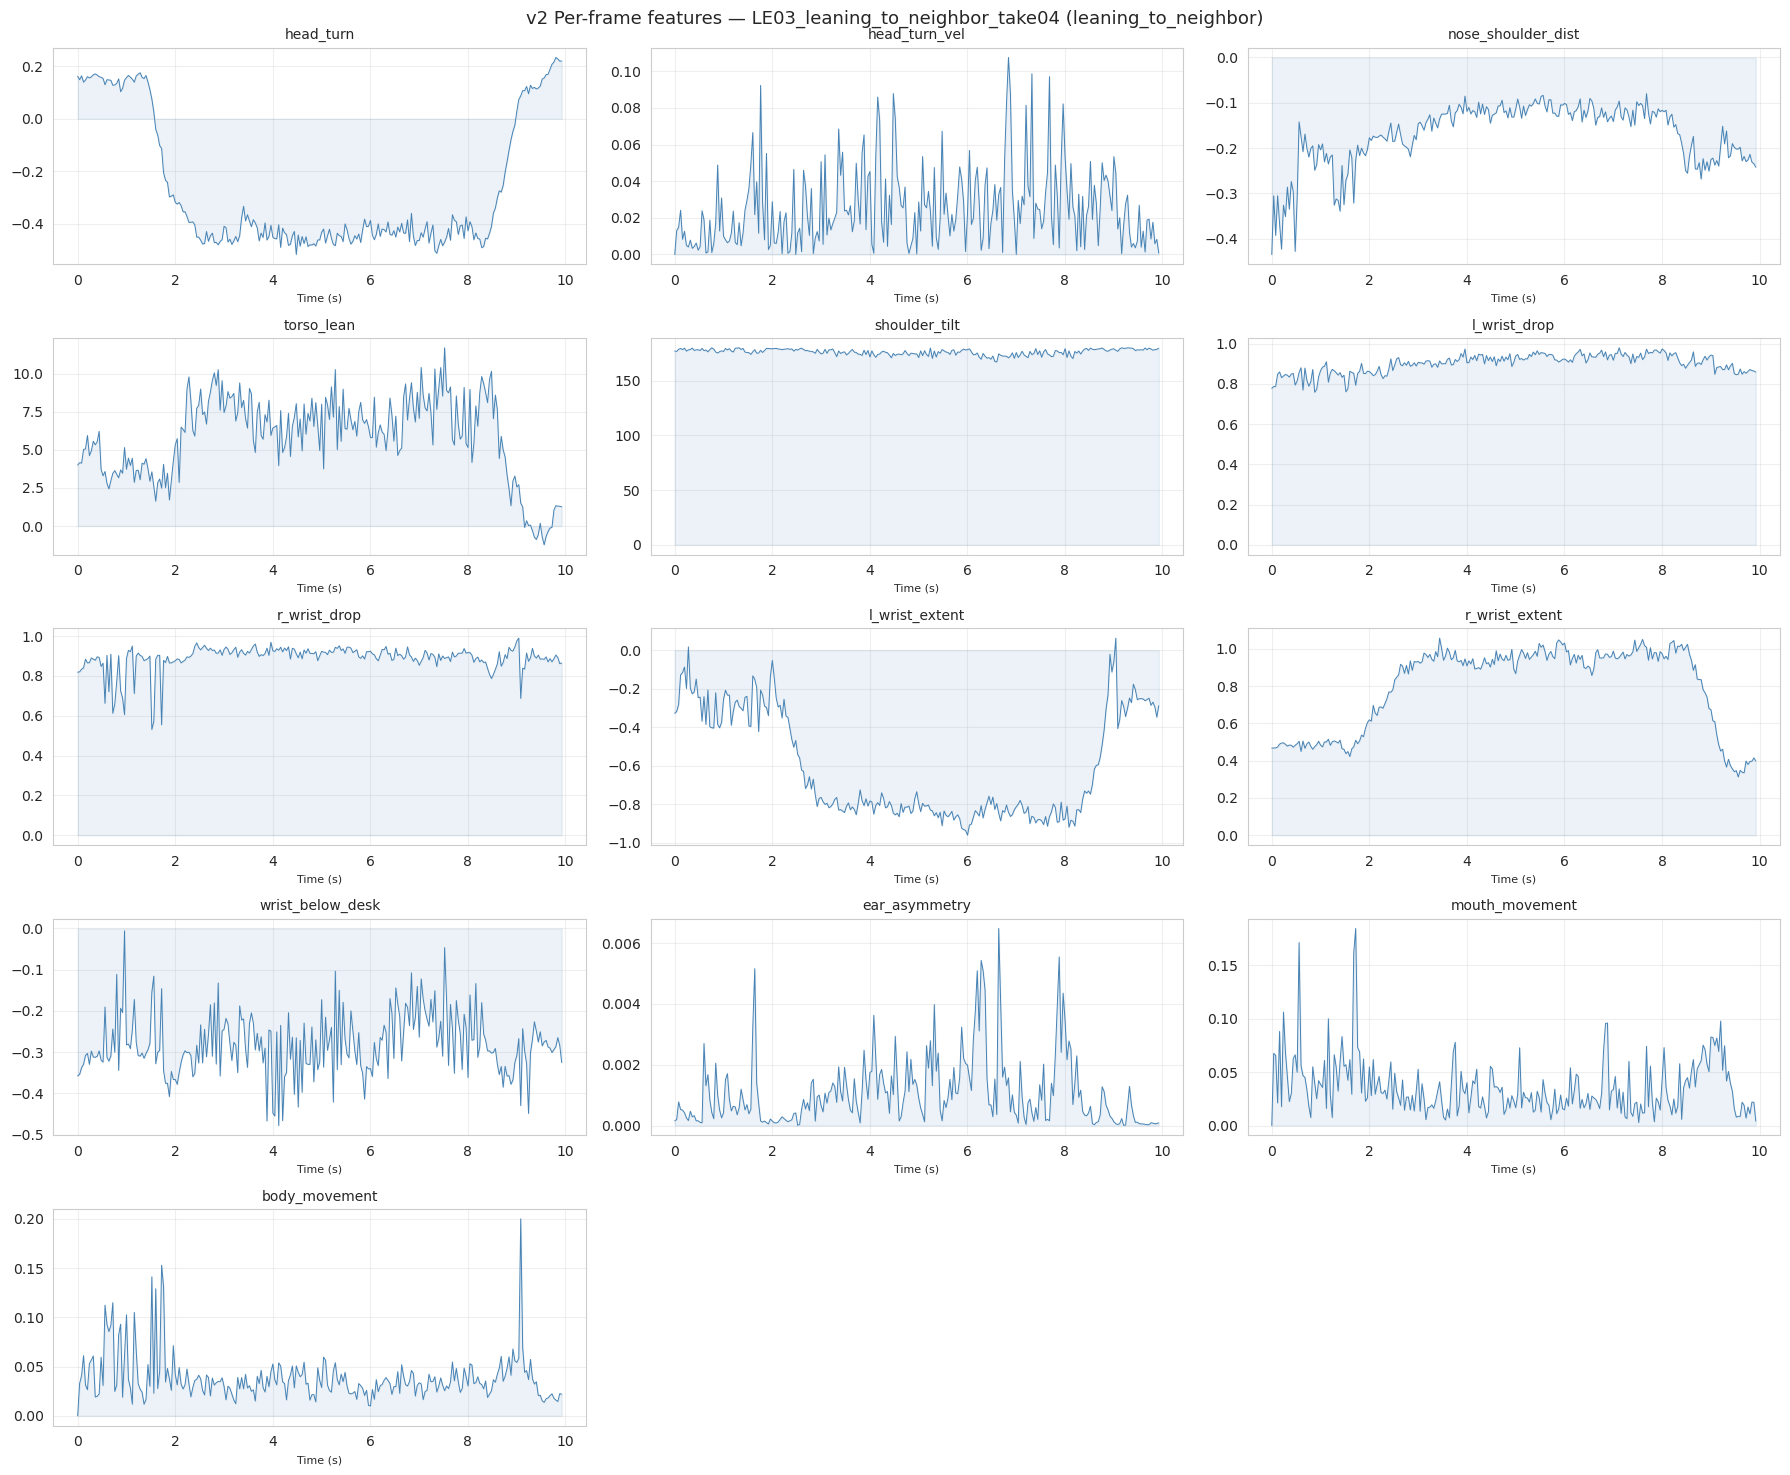

In [8]:
EXPLORE_CLIP = 'LE03_leaning_to_neighbor_take04'

npz = np.load(os.path.join(POSES_DIR, f'{EXPLORE_CLIP}.npz'), allow_pickle=True)
ex_kp = npz['keypoints']; ex_bb = npz['bbox']; ex_nd = npz['num_detected']
ex_beh = str(npz['behavior_class'])
ex_seat_raw = npz['target_seat']
ex_seat = None if str(ex_seat_raw).strip().upper() in ('', 'NAN', 'NONE') else str(ex_seat_raw).strip().upper()
ex_fps = float(npz['fps'])

mid = ex_kp.shape[0] // 2
ex_tidx = identify_target_person(ex_bb[mid], ex_nd[mid], ex_seat)
if ex_tidx < 0: ex_tidx = 0

# Compute median shoulder width for this person
ex_ref_sw = compute_median_shoulder_width(ex_kp[:, ex_tidx, :, :], ex_bb[:, ex_tidx, :])

print(f'Clip: {EXPLORE_CLIP} ({ex_beh}, seat {ex_seat})')
print(f'Target person: P{ex_tidx+1}')
print(f'Reference shoulder width: {ex_ref_sw:.1f} pixels')

# Compute v3 features
ex_ff = []
for f in range(ex_kp.shape[0]):
    kp_f = kp_to_frame_coords(ex_kp[f, ex_tidx], ex_bb[f, ex_tidx])
    prev_f = kp_to_frame_coords(ex_kp[f-1, ex_tidx], ex_bb[f-1, ex_tidx]) if f > 0 else None
    ex_ff.append(compute_frame_features_v2(kp_f, prev_f, ex_ref_sw))

# Plot all features
t = np.arange(len(ex_ff)) / ex_fps
ncols = 3; nrows = (NUM_BASE + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3*nrows))
for i, fn in enumerate(FEATURE_NAMES_V2):
    ax = axes.flat[i]
    sig = [ff[fn] for ff in ex_ff]
    ax.plot(t, sig, color='steelblue', lw=0.7)
    ax.fill_between(t, sig, alpha=0.1, color='steelblue')
    ax.set_title(fn, fontsize=10); ax.set_xlabel('Time (s)', fontsize=8)
    ax.grid(True, alpha=0.3)
for j in range(len(FEATURE_NAMES_V2), len(axes.flat)): axes.flat[j].set_visible(False)
plt.suptitle(f'v2 Per-frame features — {EXPLORE_CLIP} ({ex_beh})', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'v2_per_frame_features.png'), dpi=150, bbox_inches='tight')
plt.show()

### Active Segment + Window Labels

Active: 1.9s – 9.0s (7.2s duration)


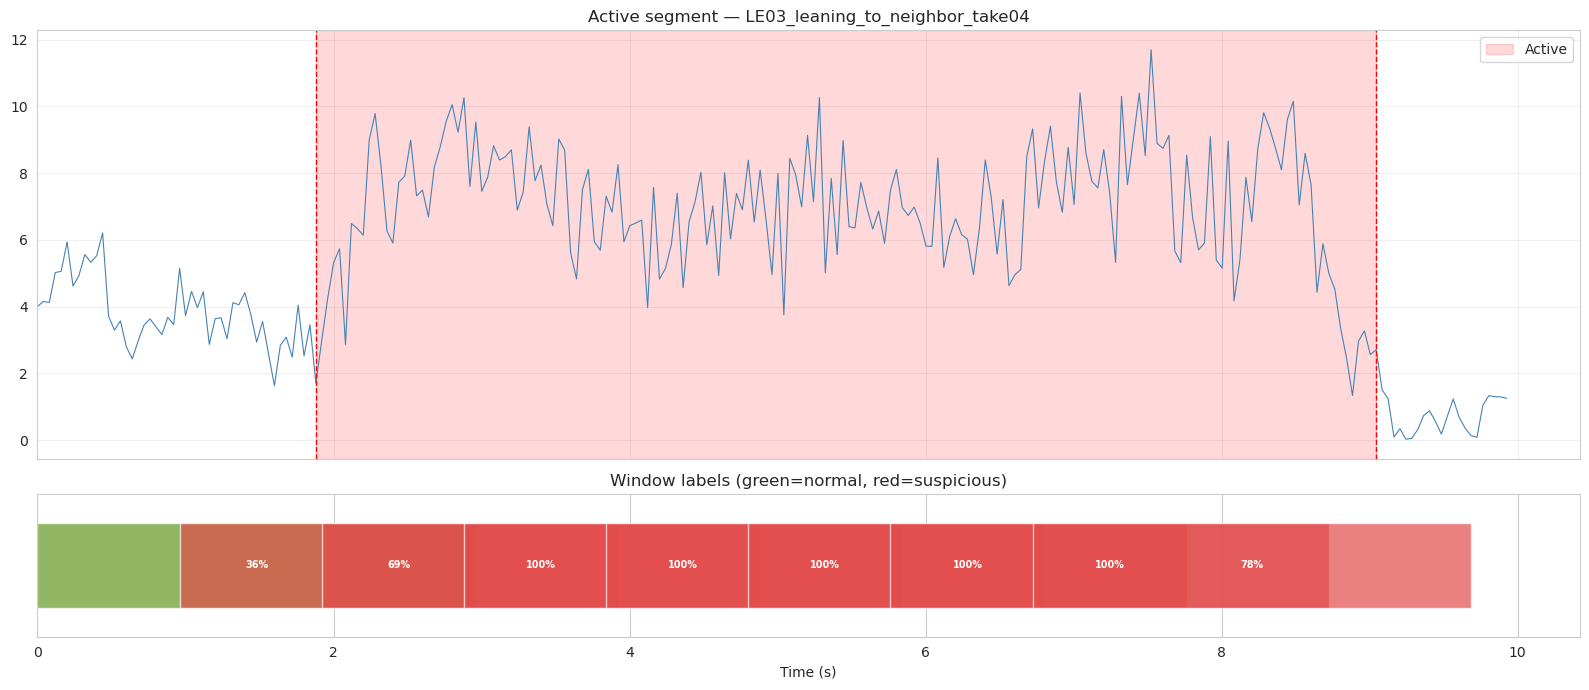


Target person: 7 suspicious + 1 normal windows
Non-target (Fix 1): only 1 person × 8 windows = 8 normal windows
v1 would have produced 7 × 8 = 56 normal windows


In [9]:
a_s, a_e = detect_active_segment(ex_ff, ex_beh, ex_fps)
print(f'Active: {a_s/ex_fps:.1f}s – {a_e/ex_fps:.1f}s ({(a_e-a_s)/ex_fps:.1f}s duration)')

# Plot
feat_map = {'looking_sideways':('head_turn',True),'looking_down':('nose_shoulder_dist',False),
    'leaning_to_neighbor':('torso_lean',True),'talking_to_neighbor':('mouth_movement',False),
    'using_phone':('wrist_below_desk',False),'passing_note':('r_wrist_extent',False),
    'normal':('body_movement',False)}
kf, use_abs = feat_map.get(ex_beh, ('body_movement', False))
sig = np.array([f[kf] for f in ex_ff])
if use_abs: sig = np.abs(sig)

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True, gridspec_kw={'height_ratios':[3,1]})
axes[0].plot(t, sig, color='steelblue', lw=0.8)
axes[0].axvspan(a_s/ex_fps, a_e/ex_fps, alpha=0.15, color='red', label='Active')
axes[0].axvline(a_s/ex_fps, color='red', lw=1, ls='--')
axes[0].axvline(a_e/ex_fps, color='red', lw=1, ls='--')
axes[0].set_title(f'Active segment — {EXPLORE_CLIP}'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

wf = int(WINDOW_SIZE_SEC * ex_fps); sf = int(WINDOW_STRIDE_SEC * ex_fps); nf = len(ex_ff)
sus_w = 0; nor_w = 0
for ws in range(0, nf - wf + 1, sf):
    we = ws + wf
    ov = max(0, min(we, a_e) - max(ws, a_s)) / wf
    is_sus = (ex_beh != 'normal' and ov >= ACTIVE_THRESHOLD)
    c = '#E24B4A' if is_sus else '#639922'
    axes[1].barh(0, (we-ws)/ex_fps, left=ws/ex_fps, height=0.6, color=c, alpha=0.7, edgecolor='white', lw=1)
    axes[1].text((ws+we)/2/ex_fps, 0, f'{ov:.0%}', ha='center', va='center', fontsize=7, color='white', fontweight='bold')
    if is_sus: sus_w += 1
    else: nor_w += 1

axes[1].set_xlabel('Time (s)'); axes[1].set_yticks([]); axes[1].set_ylim(-0.5, 0.5)
axes[1].set_title('Window labels (green=normal, red=suspicious)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'v2_active_segment.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTarget person: {sus_w} suspicious + {nor_w} normal windows')
print(f'Non-target (Fix 1): only 1 person × {sus_w+nor_w} windows = {sus_w+nor_w} normal windows')
print(f'v1 would have produced 7 × {sus_w+nor_w} = {7*(sus_w+nor_w)} normal windows')

---
## 6. Full Feature Extraction (all clips)

**Three fixes applied here:**
1. **Fix 1:** Only 1 random non-target person per clip (not 7)
2. **Fix 2:** Both binary labels and 7-class labels saved
3. **Fix 3:** Features in frame coordinates with per-person shoulder-width normalisation

**Checkpointed — safe to re-run.**

In [10]:
cached = load_checkpoint(FEATURES_CHECKPOINT)

if cached is not None:
    all_features = cached['features']
    all_labels_7 = cached['labels_7class']
    all_labels_2 = cached['labels_binary']
    all_meta = cached['meta']
    print(f'Loaded {len(all_features)} windows from checkpoint.')

else:
    print(f'Extracting v2 features from {len(df)} clips...\n')
    all_features, all_labels_7, all_labels_2, all_meta = [], [], [], []
    
    for clip_idx, (_, row) in enumerate(df.iterrows()):
        clip_stem = row['clip_stem']
        behavior = row['behavior_class']
        target_seat_raw = row.get('target_seat_id', '')
        target_seat = None if pd.isna(target_seat_raw) else str(target_seat_raw).strip().upper()
        scenario_id = row.get('scenario_id', '')
        
        if (clip_idx+1) % 50 == 0 or clip_idx == 0:
            print(f'  [{clip_idx+1}/{len(df)}] {clip_stem} ({behavior})')
        
        npz_path = os.path.join(POSES_DIR, f'{clip_stem}.npz')
        if not os.path.exists(npz_path): continue
        
        data = np.load(npz_path, allow_pickle=True)
        kps = data['keypoints']; bbs = data['bbox']; nd = data['num_detected']
        fps = float(data['fps']); nf = kps.shape[0]
        wf = int(WINDOW_SIZE_SEC * fps); sf = int(WINDOW_STRIDE_SEC * fps)
        if nf < wf: continue
        
        mid = nf // 2
        target_idx = identify_target_person(bbs[mid], nd[mid], target_seat)
        
        # ── FIX 1: Build people list — only 1 non-target ──
        people = []
        if target_idx >= 0:
            people.append((target_idx, behavior))
        
        # Pick 1 random non-target person
        n_det = int(nd[mid])
        non_targets = [p for p in range(n_det) if p != target_idx]
        if non_targets:
            chosen = np.random.choice(non_targets, size=min(MAX_NORMAL_PER_CLIP, len(non_targets)), replace=False)
            for c in chosen:
                people.append((int(c), 'normal'))
        
        for pidx, plabel in people:
            # ── FIX 3: Compute reference shoulder width ──
            ref_sw = compute_median_shoulder_width(kps[:, pidx, :, :], bbs[:, pidx, :])
            
            # Per-frame features in frame coordinates
            ffl = []
            for f in range(nf):
                if pidx >= int(nd[f]):
                    ffl.append({k: 0.0 for k in FEATURE_NAMES_V2})
                else:
                    kp_f = kp_to_frame_coords(kps[f, pidx], bbs[f, pidx])
                    prev_f = kp_to_frame_coords(kps[f-1, pidx], bbs[f-1, pidx]) if (f > 0 and pidx < int(nd[f-1])) else None
                    ffl.append(compute_frame_features_v2(kp_f, prev_f, ref_sw))
            
            ff_arr = np.array([[ff[n] for n in FEATURE_NAMES_V2] for ff in ffl], dtype=np.float32)
            
            # Active segment
            if pidx == target_idx and behavior != 'normal':
                act_s, act_e = detect_active_segment(ffl, behavior, fps)
            else:
                act_s, act_e = 0, nf
            
            # Slide windows
            for ws in range(0, nf - wf + 1, sf):
                we = ws + wf
                if plabel == 'normal':
                    wlabel_7 = 'normal'
                else:
                    ov = max(0, min(we, act_e) - max(ws, act_s))
                    wlabel_7 = behavior if (ov / wf) >= ACTIVE_THRESHOLD else 'normal'
                
                # ── FIX 2: Binary label ──
                wlabel_2 = 'suspicious' if wlabel_7 != 'normal' else 'normal'
                
                agg = aggregate_window(ff_arr[ws:we])
                agg = np.nan_to_num(agg, nan=0.0, posinf=0.0, neginf=0.0)
                
                all_features.append(agg)
                all_labels_7.append(wlabel_7)
                all_labels_2.append(wlabel_2)
                all_meta.append({
                    'clip_stem': clip_stem, 'scenario_id': scenario_id,
                    'person_idx': pidx, 'is_target': pidx == target_idx,
                    'window_start': ws, 'window_end': we,
                    'original_behavior': behavior,
                })
    
    all_features = np.array(all_features, dtype=np.float32)
    all_labels_7 = np.array(all_labels_7)
    all_labels_2 = np.array(all_labels_2)
    save_checkpoint({
        'features': all_features, 'labels_7class': all_labels_7,
        'labels_binary': all_labels_2, 'meta': all_meta,
        'feature_names': FEATURE_NAMES_V2, 'full_feature_names': FULL_FEAT_NAMES,
        'agg_names': AGG_NAMES,
    }, FEATURES_CHECKPOINT)

print(f'\nTotal windows: {len(all_features)}')
print(f'Feature shape: {all_features.shape}')
print(f'\n7-class distribution:')
for l, c in zip(*np.unique(all_labels_7, return_counts=True)):
    print(f'  {l}: {c} ({c/len(all_labels_7)*100:.1f}%)')
print(f'\nBinary distribution:')
for l, c in zip(*np.unique(all_labels_2, return_counts=True)):
    print(f'  {l}: {c} ({c/len(all_labels_2)*100:.1f}%)')

Extracting v2 features from 393 clips...

  [1/393] N01_normal_take01 (normal)


NameError: name 'aggregate_window' is not defined

### Feature Distributions (v3)

In [ ]:
df_feat = pd.DataFrame(all_features, columns=FULL_FEAT_NAMES)
df_feat['label_7'] = all_labels_7
df_feat['label_2'] = all_labels_2

# Binary distributions
key_feats = ['head_turn_range','nose_shoulder_dist_mean','torso_lean_std',
             'head_turn_vel_mean','ear_asymmetry_max','wrist_below_desk_max']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, fn in zip(axes.flat, key_feats):
    for cls in ['normal','suspicious']:
        m = df_feat['label_2'] == cls
        c = '#639922' if cls == 'normal' else '#E24B4A'
        ax.hist(df_feat.loc[m, fn], bins=50, alpha=0.5, label=cls, density=True, color=c)
    ax.set_title(fn); ax.legend()
plt.suptitle('v2 Feature distributions — Binary (normal vs suspicious)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'v2_binary_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# 7-class distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, fn in zip(axes.flat, key_feats):
    for cls in sorted(df_feat['label_7'].unique()):
        m = df_feat['label_7'] == cls
        if m.sum() > 0:
            ax.hist(df_feat.loc[m, fn], bins=50, alpha=0.4, label=cls, density=True)
    ax.set_title(fn); ax.legend(fontsize=7)
plt.suptitle('v2 Feature distributions — 7 class', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'v2_7class_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Feature importance
nor_m = df_feat[df_feat['label_2']=='normal'][FULL_FEAT_NAMES].mean()
nor_s = df_feat[df_feat['label_2']=='normal'][FULL_FEAT_NAMES].std().replace(0,1)
sus_m = df_feat[df_feat['label_2']=='suspicious'][FULL_FEAT_NAMES].mean()
effect = ((sus_m - nor_m) / nor_s).abs().sort_values(ascending=False)
print('Top 10 features separating normal from suspicious:\n')
for f, v in effect.head(10).items():
    d = 'higher' if sus_m[f] > nor_m[f] else 'lower'
    print(f'  {f}: effect={v:.3f} ({d})')

print(f'\n\nPer suspicious class:')
for cls in sorted(set(all_labels_7) - {'normal'}):
    cls_m = df_feat[df_feat['label_7']==cls][FULL_FEAT_NAMES].mean()
    eff = ((cls_m - nor_m) / nor_s).abs().sort_values(ascending=False)
    print(f'\n  {cls}:')
    for f, v in eff.head(3).items():
        print(f'    {f}: effect={v:.3f}')